# Notebook 13: Smoothing Time Series With Moving Averages

See https://towardsdatascience.com/moving-averages-in-python-16170e20f6c for a description of moving averages and how they are calculated.

We will first look at two files: one is the monthly average temperature for the city of Barcelona, Spain since 1780, the other is the monthly total rainfall for the city of Barcelona, Spain since 1786.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load the csv file monthly average air temperatures for the city of Barcelona since 1780 into a DataFrame.
from google.colab import drive
drive.mount('/content/drive')
df_temperature = pd.read_csv('drive/My Drive/Notebook13/temperaturesbarcelona1780_format_long.csv')
df_temperature.head()

Mounted at /content/drive


,Any,Mes,Desc_Mes,Temperatura
0,1780,1,Gener,6.7
1,1780,2,Febrer,7.3
2,1780,3,Març,11.6
3,1780,4,Abril,11.4
4,1780,5,Maig,16.3


In [3]:
#translate Spanish column names to English, and convert Celsius temperatues to Fahrenheit.
df_temperature.rename(columns={'Any':'Year', 'Mes':'Month',
                               'Desc_Mes': 'Month Name', 'Temperatura':'Temperature'}, inplace=True)
df_temperature.Temperature=round(df_temperature.Temperature*(9/5)+32,1)
df_temperature.head()

,Year,Month,Month Name,Temperature
0,1780,1,Gener,44.1
1,1780,2,Febrer,45.1
2,1780,3,Març,52.9
3,1780,4,Abril,52.5
4,1780,5,Maig,61.3


In [4]:
# load the csv file monthly total rainfall for the city of Barcelona since 1786 into a DataFrame.
df_rainfall = pd.read_csv('drive/My Drive/Notebook13/precipitacionsbarcelona1786_format_long.csv')
df_rainfall.head()

,Any,Mes,Desc_Mes,Precipitacions
0,1786,1,Gener,32.8
1,1786,2,Febrer,28.4
2,1786,3,Març,84.4
3,1786,4,Abril,42.3
4,1786,5,Maig,8.5


In [5]:
#translate Spanish column names to English, and convert millimeter rainfall measurements to inches.
df_rainfall.rename(columns={'Any':'Year', 'Mes':'Month',
                            'Desc_Mes': 'Month Name', 'Precipitacions':'Rainfall'}, inplace=True)
df_rainfall.Rainfall=round(df_rainfall.Rainfall/25.4,1)
df_rainfall.head()

,Year,Month,Month Name,Rainfall
0,1786,1,Gener,1.3
1,1786,2,Febrer,1.1
2,1786,3,Març,3.3
3,1786,4,Abril,1.7
4,1786,5,Maig,0.3


Plot all of the temperature data, and all of the rainfall data. For both, there is so much data with so much variability that we cannot easily see what is going on!

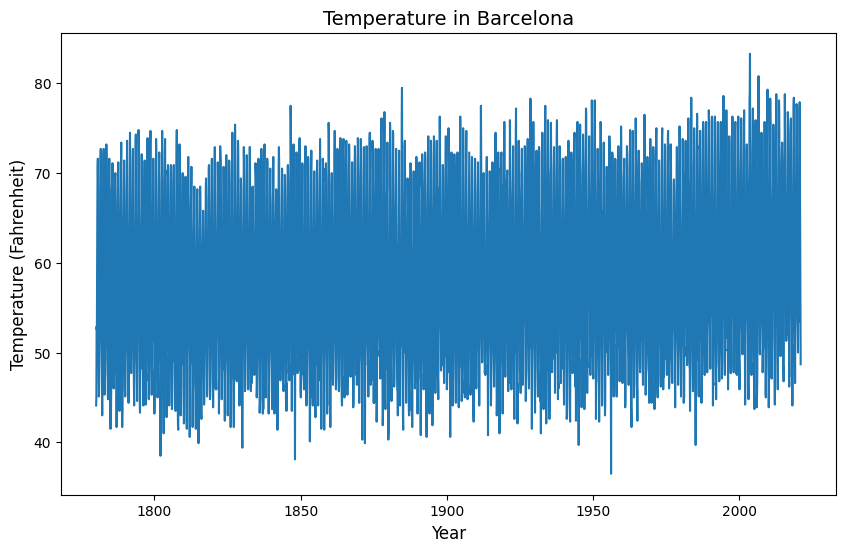

In [6]:
plt.figure(figsize=(10,6))
plt.plot(df_temperature.Year+df_temperature.Month/12,df_temperature.Temperature)
plt.xlabel('Year',fontsize=12)
plt.ylabel('Temperature (Fahrenheit)',fontsize=12)
plt.title('Temperature in Barcelona',fontsize=14)
plt.show()

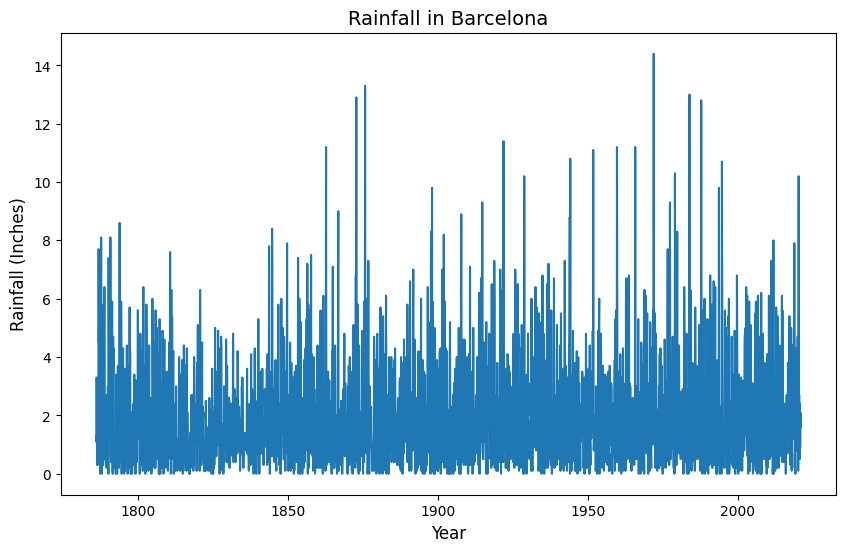

In [7]:
plt.figure(figsize=(10,6))
plt.plot(df_rainfall.Year+df_rainfall.Month/12,df_rainfall.Rainfall)
plt.xlabel('Year',fontsize=12)
plt.ylabel('Rainfall (Inches)',fontsize=12)
plt.title('Rainfall in Barcelona',fontsize=14)
plt.show()

First, let's average the temperature values by year to smooth out the differences between summer and winter. We use .groupby.mean() to do this. Note the use of as_index=False to retain Year as a column that we can reference rather than it being set as the new index.

In [8]:
yearly_temp=df_temperature[['Year', 'Temperature']].groupby('Year',as_index=False).mean()
yearly_temp.head()

,Year,Temperature
0,1780,57.325000
1,1781,58.483333
2,1782,56.533333
3,1783,57.916667
4,1784,56.508333


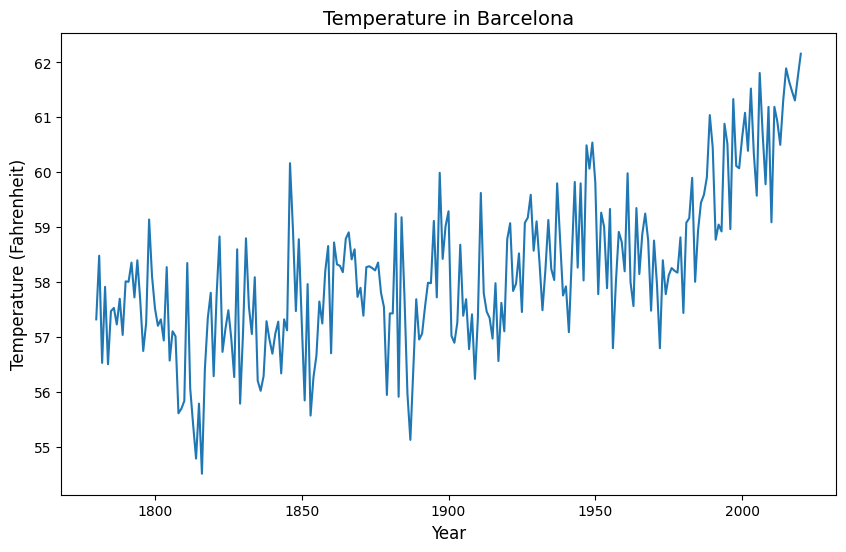

In [9]:
plt.figure(figsize=(10,6))
plt.plot(yearly_temp.Year,yearly_temp.Temperature)
plt.xlabel('Year',fontsize=12)
plt.ylabel('Temperature (Fahrenheit)',fontsize=12)
plt.title('Temperature in Barcelona',fontsize=14)
plt.show()

## Exercise 1:
Do something similar for the rainfall DataFrame, but compute the yearly **total** rainfall (use .sum() instead of .mean() for your groupby). Then plot the yearly total rainfall versus time as we did for the yearly average temperature above. Your answer should look like the answer1.png file included with this notebook.

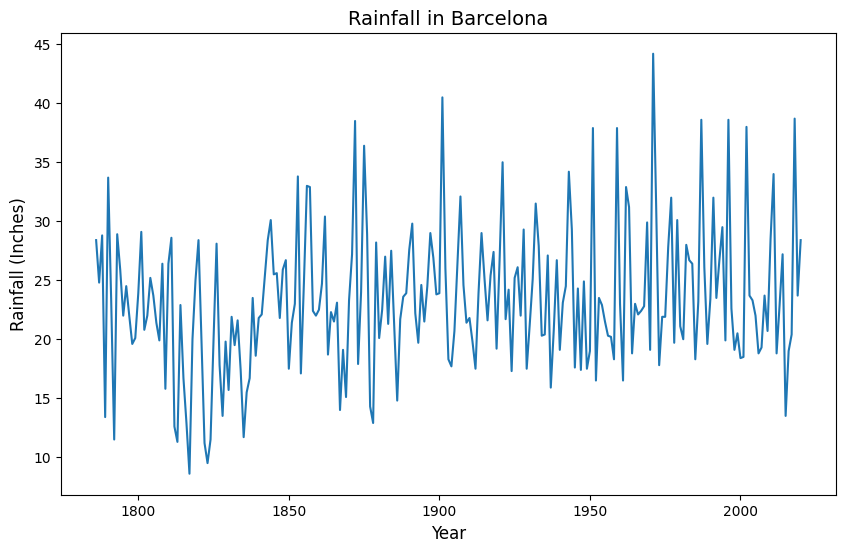

In [14]:
### YOUR CODE HERE!
# yearly_temp=df_temperature[['Year', 'Temperature']].groupby('Year',as_index=False).mean()
# yearly_temp.head()
yearly_rainfall=df_rainfall[['Year', 'Rainfall']].groupby('Year',as_index=False).sum()
yearly_rainfall.head()

plt.figure(figsize=(10,6))
plt.plot(yearly_rainfall.Year,yearly_rainfall.Rainfall)
plt.xlabel('Year',fontsize=12)
plt.ylabel('Rainfall (Inches)',fontsize=12)
plt.title('Rainfall in Barcelona',fontsize=14)
plt.show()

### YOUR PLOT HERE!

There is still a lot of short-scale time variability in the plots that makes it hard to visualize long-term trends. We can account for this using moving or rolling averages, or 'smoothing', which will naturally smooth out the spikiness of the data. See the link at the top of the notebook for more information on moving averages. We will look at 10 year and 20 year simpe moving averages. These can be applied using the .rolling.mean() method applied to the DataFrame column.

In [10]:
yearly_temp['SMA_10'] = yearly_temp.Temperature.rolling(10, min_periods=1).mean()
yearly_temp['SMA_20'] = yearly_temp.Temperature.rolling(20, min_periods=1).mean()
yearly_temp.head(15)

,Year,Temperature,SMA_10,SMA_20
0,1780,57.325000,57.325000,57.325000
1,1781,58.483333,57.904167,57.904167
2,1782,56.533333,57.447222,57.447222
3,1783,57.916667,57.564583,57.564583
4,1784,56.508333,57.353333,57.353333
5,1785,57.475000,57.373611,57.373611
6,1786,57.533333,57.396429,57.396429
7,1787,57.233333,57.376042,57.376042
8,1788,57.700000,57.412037,57.412037
9,1789,57.041667,57.375000,57.375000


We plot the yearly average temperature, 10-year moving average, and 20-year moving average on the same graph. By the time we get to the 20-year moving average the short-term variability is gone, and we can clearly see the warming that has taken place since about 1970.

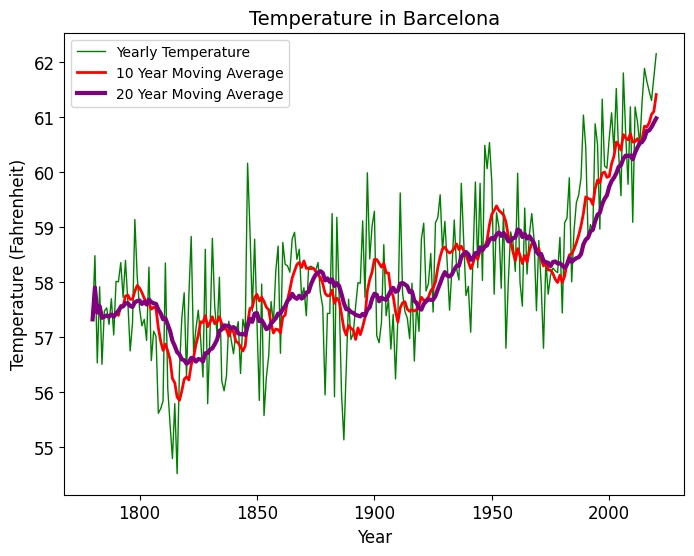

In [11]:
plt.figure(figsize=(8,6))
plt.plot(yearly_temp.Year,yearly_temp.Temperature,color='green',linewidth=1,label='Yearly Temperature')
plt.plot(yearly_temp.Year,yearly_temp.SMA_10,color='red',linewidth=2,label='10 Year Moving Average')
plt.plot(yearly_temp.Year,yearly_temp.SMA_20,color='purple',linewidth=3,label='20 Year Moving Average')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Temperature (Fahrenheit)',fontsize=12)
plt.title('Temperature in Barcelona',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.show()

## Exercise 2:
Do something similar for the rainfall DataFrame. Plot the yearly total rainfall, 10-year moving average, and 20-year moving average versus time all on the same plot, as we did for the temperature DataFrame above. Your answer should look like the answer2.png file included with this notebook.

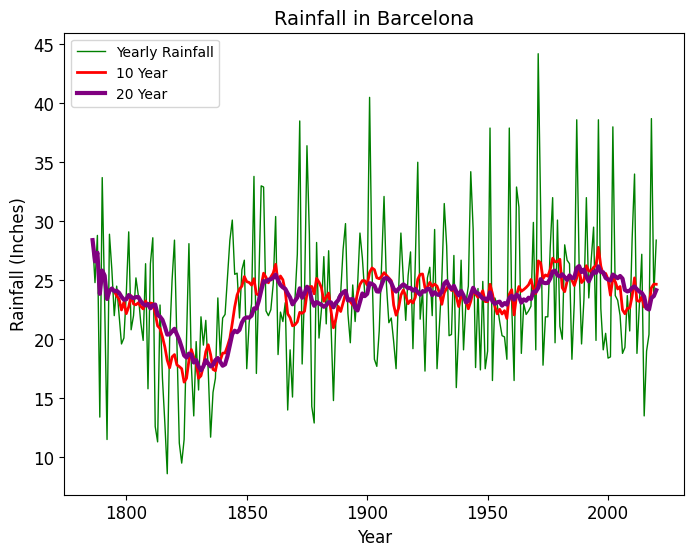

In [16]:
### YOUR CODE HERE!
# yearly_temp['SMA_10'] = yearly_temp.Temperature.rolling(10, min_periods=1).mean()
# yearly_temp['SMA_20'] = yearly_temp.Temperature.rolling(20, min_periods=1).mean()
# yearly_temp.head(15)

yearly_rainfall['SMA_10'] = yearly_rainfall.Rainfall.rolling(10, min_periods=1).mean()
yearly_rainfall['SMA_20'] = yearly_rainfall.Rainfall.rolling(20, min_periods=1).mean()
yearly_rainfall.head(15)

### YOUR PLOT HERE!
plt.figure(figsize=(8,6))
plt.plot(yearly_rainfall.Year,yearly_rainfall.Rainfall,color='green',linewidth=1,label='Yearly Rainfall')
plt.plot(yearly_rainfall.Year,yearly_rainfall.SMA_10,color='red',linewidth=2,label='10 Year')
plt.plot(yearly_rainfall.Year,yearly_rainfall.SMA_20,color='purple',linewidth=3,label='20 Year')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Rainfall (Inches)',fontsize=12)
plt.title('Rainfall in Barcelona',fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.show()

## Stock Prices:
Next we will look at a file containing the Dow Jones Industrial Average values from 1896 through the present.
We load the file with the parse_dates method so that the 'Date' column should get loaded as datetime variable type.

In [17]:
df_stocks = pd.read_csv('drive/My Drive/Notebook13/dji.csv',parse_dates=[0])
df_stocks

,Date,Open,High,Low,Close,Volume
0,1896-05-27,29.39,29.39,29.39,29.39,NaN
1,1896-05-28,29.11,29.11,29.11,29.11,NaN
2,1896-05-29,29.43,29.43,29.43,29.43,NaN
3,1896-06-01,29.40,29.40,29.40,29.40,NaN
4,1896-06-02,29.00,29.00,29.00,29.00,NaN
...,...,...,...,...,...,...
32547,2022-01-10,36175.21,36175.21,35639.91,36068.87,488023456.0
32548,2022-01-11,36058.85,36271.47,35769.38,36252.02,421210623.0
32549,2022-01-12,36336.16,36453.49,36168.15,36290.32,361798146.0
32550,2022-01-13,36312.49,36513.88,36044.22,36113.62,395636110.0


In [18]:
df_stocks.Date.head() #check that it has type datetime, it does.

,Date
0,1896-05-27
1,1896-05-28
2,1896-05-29
3,1896-06-01
4,1896-06-02


In [19]:
df_stocks['Year']=df_stocks.Date.dt.year #extract a year column from the date column so we can filter by year.
df_stocks.head()

,Date,Open,High,Low,Close,Volume,Year
0,1896-05-27,29.39,29.39,29.39,29.39,NaN,1896
1,1896-05-28,29.11,29.11,29.11,29.11,NaN,1896
2,1896-05-29,29.43,29.43,29.43,29.43,NaN,1896
3,1896-06-01,29.40,29.40,29.40,29.40,NaN,1896
4,1896-06-02,29.00,29.00,29.00,29.00,NaN,1896


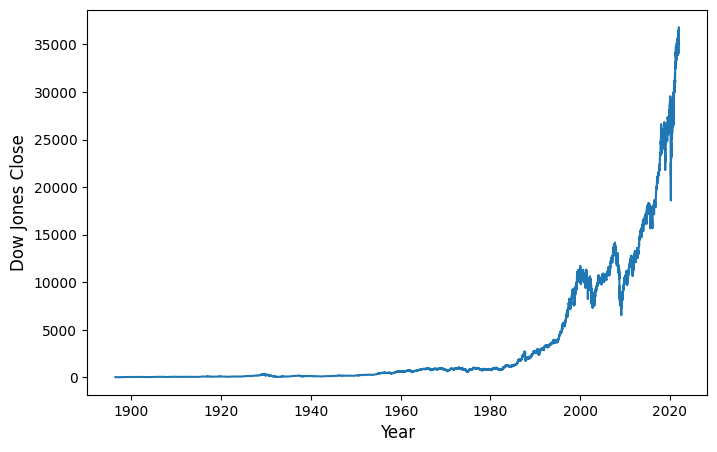

In [20]:
#Take a look at the entire time range.
plt.figure(figsize=(8,5))
plt.plot(df_stocks.Date,df_stocks.Close)
plt.xlabel('Year',fontsize=12)
plt.ylabel('Dow Jones Close',fontsize=12)
plt.show()

## Exercise 3:
Write a function stock_year_plot that accepts the stocks DataFrame and a year, and then produces a plot with two curves: the Dow Jones closing price on each day for that year, and also the 7-day moving average of the closing price.

In [33]:
def stock_year_plot(df_stocks,plotyear):

    ### YOUR CODE HERE!
    df_stocks_year = df_stocks[df_stocks.Year == plotyear].copy()  # Make an explicit copy
    df_stocks_year['SMA_7'] = df_stocks_year.Close.rolling(7, min_periods=1).mean()
    plt.figure(figsize=(8,5))
    plt.plot(df_stocks_year.Date,df_stocks_year.Close,label='Daily Close')
    plt.plot(df_stocks_year.Date,df_stocks_year.SMA_7,color='red',label='7 Day Moving Average')
    plt.xlabel('Year',fontsize=12)
    plt.ylabel('Dow Jones Close',fontsize=12)
    plt.title('Dow Jones Index For 2008',fontsize=14)
    plt.legend()
    plt.show()

    ### YOUR PLOT HERE!
    # df_stocks_year=df_stocks[df_stocks.Year==plotyear]
    # df_stocks_year['SMA_7'] = df_stocks_year.Close.rolling(7, min_periods=1).mean()


    return

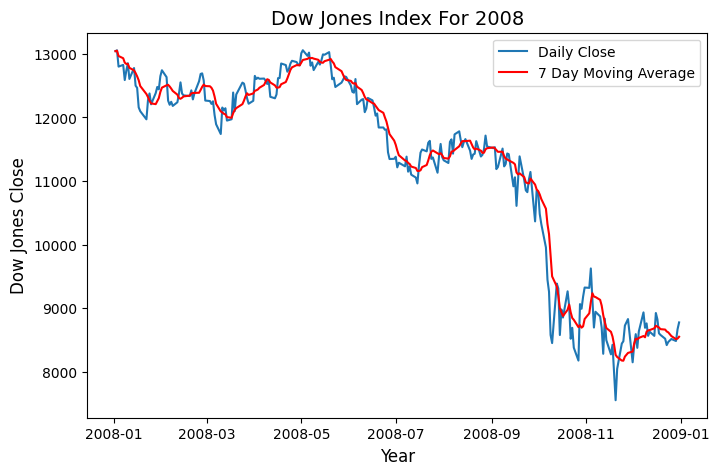

In [34]:
#Let's look at the year of the "Great Recession" in 2008:

stock_year_plot(df_stocks,2008)

#Your answer should look like the answer3.png file included with this notebook.

# You might also try these years: 1929: Great Depression, 2002: Dot Com Crash, and 2020: COVID-19

The concept of moving averages can be extended beyond 1-dimension. When a moving average is applied to a two-dimensional image it is called a "convolution", and is extremely important in image processing, including in observational astronomy.